In [21]:
%matplotlib inline

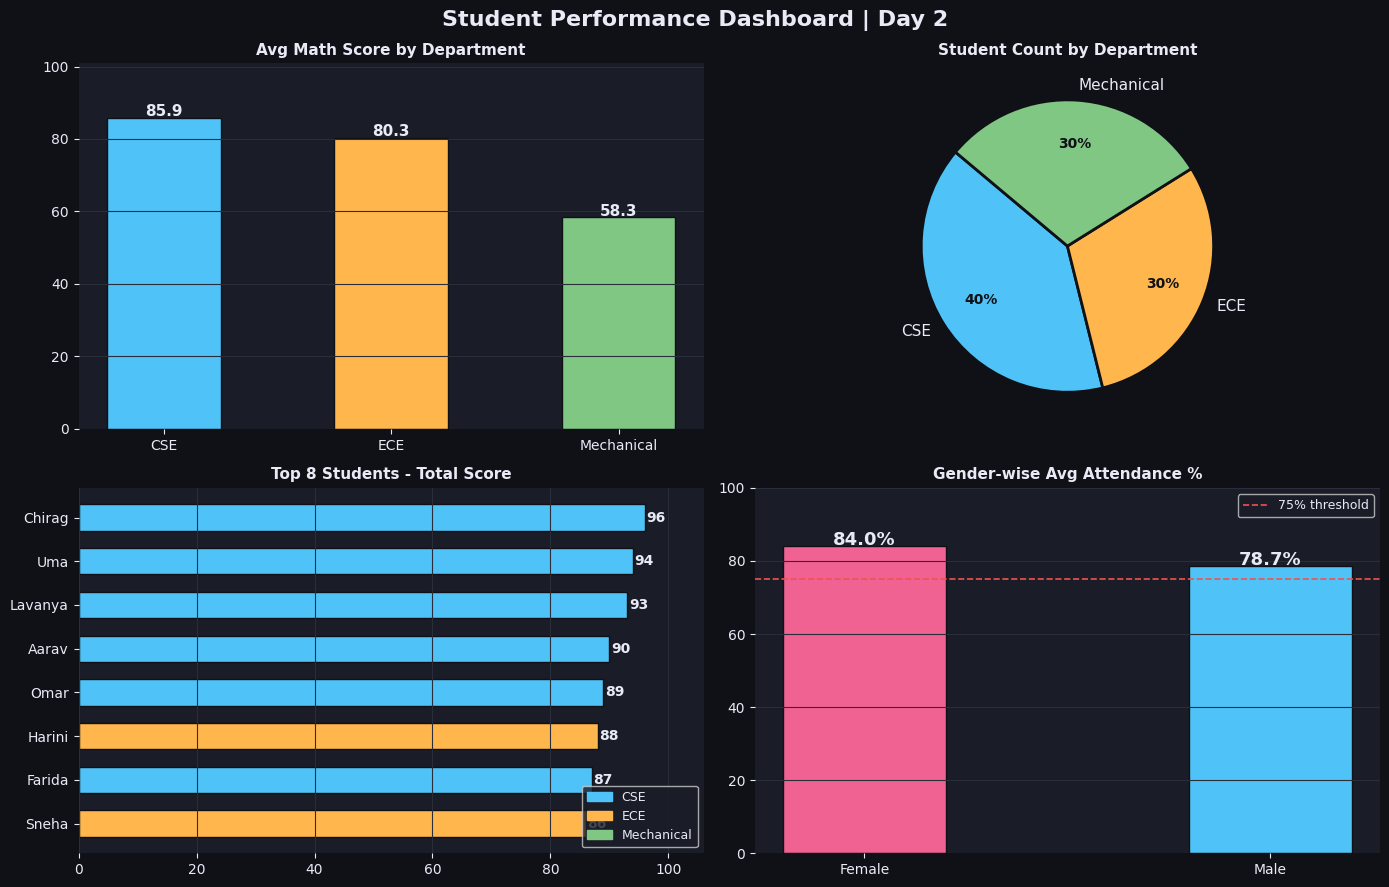

In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Colors
DARK_BG  = "#0f1117"
CARD_BG  = "#1a1d27"
ACCENT1  = "#4fc3f7"
ACCENT2  = "#81c784"
ACCENT3  = "#ffb74d"
ACCENT4  = "#f06292"
TEXT_CLR = "#e8eaf6"
SUB_CLR  = "#90a4ae"
DEPT_COLORS = {"CSE": ACCENT1, "ECE": ACCENT3, "Mechanical": ACCENT2}

# DB setup
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()
cursor.execute("""CREATE TABLE students (
    name TEXT, gender TEXT, department TEXT,
    math_score INTEGER, programming_score INTEGER,
    attendance_percentage REAL, total_score INTEGER)""")

students_data = [
    ("Aarav","Male","CSE",88,92,92.0,90),("Bhavya","Female","ECE",72,65,80.0,68),
    ("Chirag","Male","CSE",95,98,98.0,96),("Divya","Female","Mechanical",60,55,70.0,57),
    ("Elan","Male","ECE",78,80,85.0,79),("Farida","Female","CSE",85,89,95.0,87),
    ("Gopal","Male","Mechanical",55,50,60.0,52),("Harini","Female","ECE",90,87,88.0,88),
    ("Ishaan","Male","CSE",70,74,75.0,72),("Jaya","Female","Mechanical",65,60,72.0,62),
    ("Karan","Male","ECE",82,78,83.0,80),("Lavanya","Female","CSE",91,95,97.0,93),
    ("Manoj","Male","Mechanical",48,45,55.0,46),("Nisha","Female","ECE",76,70,78.0,73),
    ("Omar","Male","CSE",88,91,90.0,89),("Priya","Female","Mechanical",63,58,68.0,60),
    ("Rahul","Male","CSE",77,83,87.0,80),("Sneha","Female","ECE",84,88,93.0,86),
    ("Tarun","Male","Mechanical",59,52,62.0,55),("Uma","Female","CSE",93,96,99.0,94),
]
cursor.executemany("INSERT INTO students VALUES (?,?,?,?,?,?,?)", students_data)
conn.commit()

# SQL Queries
df_math   = pd.read_sql_query("SELECT department, ROUND(AVG(math_score),2) AS avg_math FROM students GROUP BY department ORDER BY avg_math DESC", conn)
df_count  = pd.read_sql_query("SELECT department, COUNT(*) AS student_count FROM students GROUP BY department", conn)
df_top8   = pd.read_sql_query("SELECT name, department, total_score FROM students ORDER BY total_score DESC LIMIT 8", conn)
df_gender = pd.read_sql_query("SELECT gender, ROUND(AVG(attendance_percentage),2) AS avg_attendance FROM students GROUP BY gender", conn)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle("Student Performance Dashboard | Day 2",
             fontsize=16, fontweight="bold", color=TEXT_CLR, y=0.98)

# Panel 1 - Avg Math Bar
ax1 = axes[0][0]
ax1.set_facecolor(CARD_BG)
colors1 = [DEPT_COLORS[d] for d in df_math["department"]]
bars = ax1.bar(df_math["department"], df_math["avg_math"], color=colors1, width=0.5, edgecolor=DARK_BG)
for bar, val in zip(bars, df_math["avg_math"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{val:.1f}",
             ha="center", color=TEXT_CLR, fontsize=11, fontweight="bold")
ax1.set_title("Avg Math Score by Department", color=TEXT_CLR, fontsize=11, fontweight="bold")
ax1.set_facecolor(CARD_BG)
ax1.tick_params(colors=TEXT_CLR)
ax1.spines[:].set_visible(False)
ax1.yaxis.grid(True, color="#2a2d3a")
ax1.set_ylim(0, max(df_math["avg_math"])+15)
for lbl in ax1.get_xticklabels(): lbl.set_color(TEXT_CLR)

# Panel 2 - Pie Chart
ax2 = axes[0][1]
ax2.set_facecolor(CARD_BG)
pie_colors = [DEPT_COLORS[d] for d in df_count["department"]]
wedges, texts, autotexts = ax2.pie(df_count["student_count"], labels=df_count["department"],
    autopct="%1.0f%%", colors=pie_colors, startangle=140,
    wedgeprops=dict(edgecolor=DARK_BG, linewidth=2), pctdistance=0.7)
for t in texts: t.set_color(TEXT_CLR); t.set_fontsize(11)
for at in autotexts: at.set_color(DARK_BG); at.set_fontsize(10); at.set_fontweight("bold")
ax2.set_title("Student Count by Department", color=TEXT_CLR, fontsize=11, fontweight="bold")

# Panel 3 - Top 8 Horizontal Bar
ax3 = axes[1][0]
ax3.set_facecolor(CARD_BG)
bar_colors = [DEPT_COLORS[d] for d in df_top8["department"]]
hbars = ax3.barh(df_top8["name"][::-1], df_top8["total_score"][::-1],
                 color=bar_colors[::-1], height=0.6, edgecolor=DARK_BG)
for bar, val in zip(hbars, df_top8["total_score"][::-1]):
    ax3.text(val+0.3, bar.get_y()+bar.get_height()/2, str(val),
             va="center", color=TEXT_CLR, fontsize=10, fontweight="bold")
ax3.set_title("Top 8 Students - Total Score", color=TEXT_CLR, fontsize=11, fontweight="bold")
ax3.tick_params(colors=TEXT_CLR)
ax3.spines[:].set_visible(False)
ax3.xaxis.grid(True, color="#2a2d3a")
ax3.set_xlim(0, max(df_top8["total_score"])+10)
for lbl in ax3.get_yticklabels(): lbl.set_color(TEXT_CLR)
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in DEPT_COLORS.items()]
ax3.legend(handles=legend_patches, loc="lower right", facecolor=CARD_BG, labelcolor=TEXT_CLR, fontsize=9)

# Panel 4 - Gender Attendance Bar
ax4 = axes[1][1]
ax4.set_facecolor(CARD_BG)
g_colors = [ACCENT1 if g=="Male" else ACCENT4 for g in df_gender["gender"]]
gbars = ax4.bar(df_gender["gender"], df_gender["avg_attendance"],
                color=g_colors, width=0.4, edgecolor=DARK_BG)
for bar, val in zip(gbars, df_gender["avg_attendance"]):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{val:.1f}%",
             ha="center", color=TEXT_CLR, fontsize=13, fontweight="bold")
ax4.set_title("Gender-wise Avg Attendance %", color=TEXT_CLR, fontsize=11, fontweight="bold")
ax4.set_ylim(0, 100)
ax4.axhline(75, color="#ef5350", linestyle="--", linewidth=1.2, label="75% threshold")
ax4.tick_params(colors=TEXT_CLR)
ax4.spines[:].set_visible(False)
ax4.yaxis.grid(True, color="#2a2d3a")
ax4.legend(facecolor=CARD_BG, labelcolor=TEXT_CLR, fontsize=9)
for lbl in ax4.get_xticklabels(): lbl.set_color(TEXT_CLR)

plt.tight_layout()
plt.show()

conn.close()

In [27]:
import sqlite3
import pandas as pd
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()
cursor.execute("""CREATE TABLE students (
    name TEXT, gender TEXT, department TEXT,
    math_score INTEGER, programming_score INTEGER,
    attendance_percentage REAL, total_score INTEGER)""")

students_data = [
    ("Aarav","Male","CSE",88,92,92.0,90),("Bhavya","Female","ECE",72,65,80.0,68),
    ("Chirag","Male","CSE",95,98,98.0,96),("Divya","Female","Mechanical",60,55,70.0,57),
    ("Elan","Male","ECE",78,80,85.0,79),("Farida","Female","CSE",85,89,95.0,87),
    ("Gopal","Male","Mechanical",55,50,60.0,52),("Harini","Female","ECE",90,87,88.0,88),
    ("Ishaan","Male","CSE",70,74,75.0,72),("Jaya","Female","Mechanical",65,60,72.0,62),
    ("Karan","Male","ECE",82,78,83.0,80),("Lavanya","Female","CSE",91,95,97.0,93),
    ("Manoj","Male","Mechanical",48,45,55.0,46),("Nisha","Female","ECE",76,70,78.0,73),
    ("Omar","Male","CSE",88,91,90.0,89),("Priya","Female","Mechanical",63,58,68.0,60),
    ("Rahul","Male","CSE",77,83,87.0,80),("Sneha","Female","ECE",84,88,93.0,86),
    ("Tarun","Male","Mechanical",59,52,62.0,55),("Uma","Female","CSE",93,96,99.0,94),
]
cursor.executemany("INSERT INTO students VALUES (?,?,?,?,?,?,?)", students_data)
conn.commit()

print("=" * 55)
print("      PRACTICE QUESTIONS - ANSWERS")
print("=" * 55)
q1 = pd.read_sql_query("""
    SELECT ROUND(AVG(programming_score), 2) AS avg_prog_female
    FROM students
    WHERE gender = 'Female'
""", conn)
print(f"\nQ1. Avg programming score (Female) : {q1.iloc[0,0]}")

print("""
Q2. WHERE vs HAVING
    WHERE  - Filters ROWS before grouping
    HAVING - Filters GROUPS after GROUP BY

    WHERE example:
      SELECT * FROM students WHERE math_score > 80

    HAVING example:
      SELECT department, AVG(math_score)
      FROM students
      GROUP BY department
      HAVING AVG(math_score) > 75""")

q3 = pd.read_sql_query("""
    SELECT department, ROUND(AVG(attendance_percentage), 2) AS avg_att
    FROM students
    GROUP BY department
    HAVING AVG(attendance_percentage) > 85
""", conn)
print("\nQ3. Departments with avg attendance > 85%:")
print(q3.to_string(index=False))

print("""
Q4. pd.read_sql_query()
    Returns  : Pandas DataFrame
    Arguments: (1) sql string  (2) connection object""")

q5 = pd.read_sql_query("""
    SELECT department, ROUND(AVG(programming_score), 2) AS avg_prog
    FROM students
    GROUP BY department
    ORDER BY avg_prog DESC
""", conn)
print("\nQ5. Avg Programming Score by Department:")
print(q5.to_string(index=False))

print("\n" + "=" * 55)
print("         ALL QUESTIONS DONE!")
print("=" * 55)

      PRACTICE QUESTIONS - ANSWERS

Q1. Avg programming score (Female) : 76.3

Q2. WHERE vs HAVING
    WHERE  - Filters ROWS before grouping
    HAVING - Filters GROUPS after GROUP BY

    WHERE example:
      SELECT * FROM students WHERE math_score > 80

    HAVING example:
      SELECT department, AVG(math_score)
      FROM students
      GROUP BY department
      HAVING AVG(math_score) > 75

Q3. Departments with avg attendance > 85%:
department  avg_att
       CSE    91.63

Q4. pd.read_sql_query()
    Returns  : Pandas DataFrame
    Arguments: (1) sql string  (2) connection object

Q5. Avg Programming Score by Department:
department  avg_prog
       CSE     89.75
       ECE     78.00
Mechanical     53.33

         ALL QUESTIONS DONE!
